Cybersecurity Attack Analysis using Exploratory Data Analysis (EDA)

Objective:
To analyze cybersecurity attack records, identify attack patterns, severity levels, protocol usage, anomaly behavior, and generate actionable insights for improving network security.

In [4]:
import pandas as pd

df = pd.read_csv("cybersecurity attack.csv")

df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,30-05-2023 06:33,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,26-08-2020 07:08,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,13-11-2022 08:23,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,02-07-2023 10:38,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,16-07-2023 13:11,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [5]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (40000, 25)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [7]:
print(df.columns.tolist())

['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
Alerts/Warnings,20067
IDS/IPS Alerts,20050
Malware Indicators,20000
Firewall Logs,19961
Proxy Information,19851
Source IP Address,0
Destination IP Address,0
Source Port,0
Timestamp,0
Traffic Type,0


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


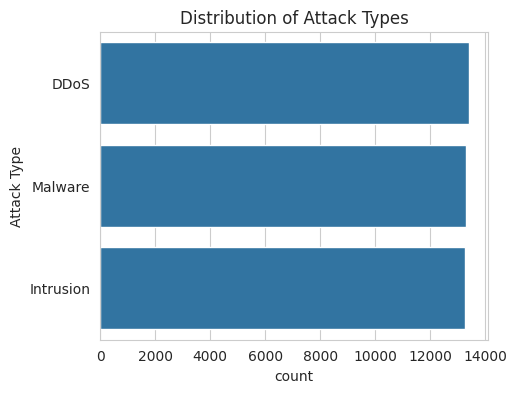

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.countplot(
    y='Attack Type',
    data=df,
    order=df['Attack Type'].value_counts().index
)

plt.title("Distribution of Attack Types")
plt.show()

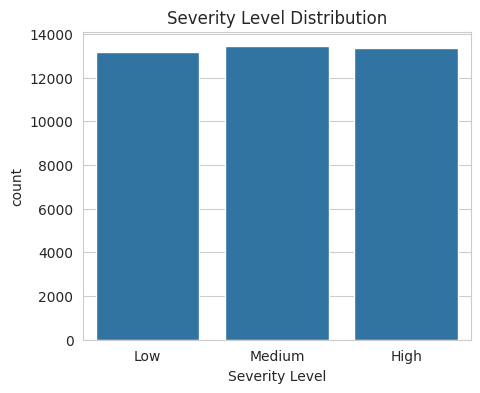

In [13]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='Severity Level',
    data=df
)

plt.title("Severity Level Distribution")
plt.show()

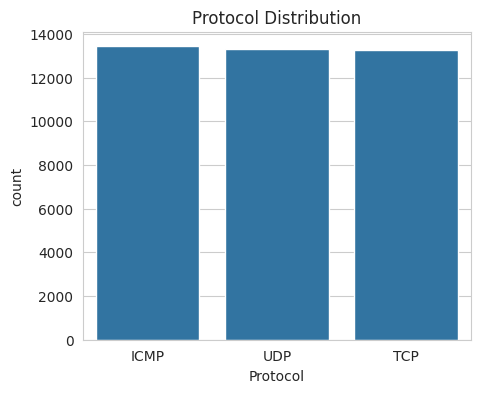

In [16]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='Protocol',
    data=df
)

plt.title("Protocol Distribution")
plt.show()

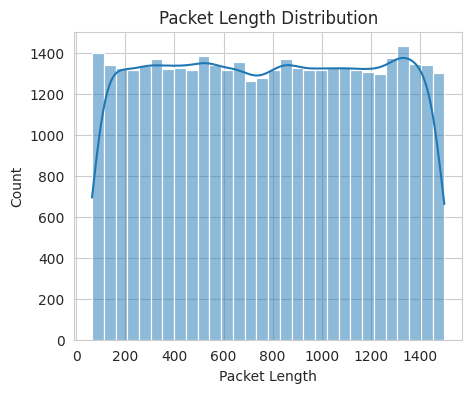

In [18]:
plt.figure(figsize=(5,4))

sns.histplot(
    df['Packet Length'],
    bins=30,
    kde=True
)

plt.title("Packet Length Distribution")
plt.show()

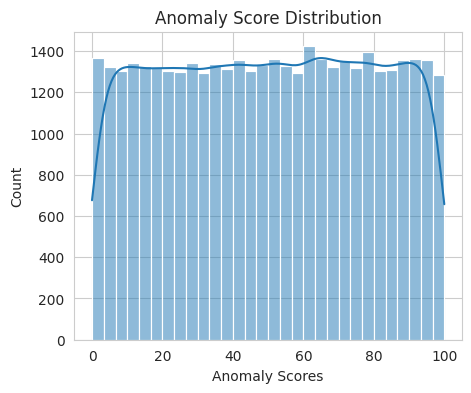

In [20]:
plt.figure(figsize=(5,4))

sns.histplot(
    df['Anomaly Scores'],
    bins=30,
    kde=True
)

plt.title("Anomaly Score Distribution")
plt.show()

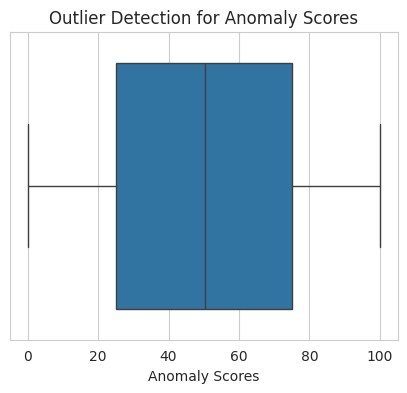

In [21]:
plt.figure(figsize=(5,4))

sns.boxplot(
    x=df['Anomaly Scores']
)

plt.title("Outlier Detection for Anomaly Scores")
plt.show()

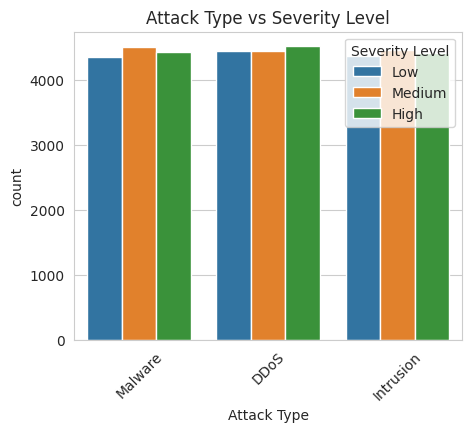

In [23]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='Attack Type',
    hue='Severity Level',
    data=df
)

plt.xticks(rotation=45)
plt.title("Attack Type vs Severity Level")
plt.show()

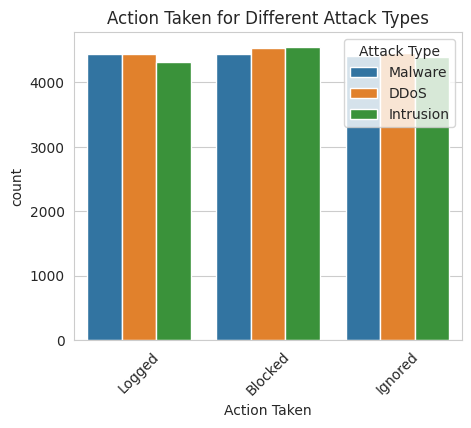

In [25]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='Action Taken',
    hue='Attack Type',
    data=df
)

plt.xticks(rotation=45)
plt.title("Action Taken for Different Attack Types")
plt.show()

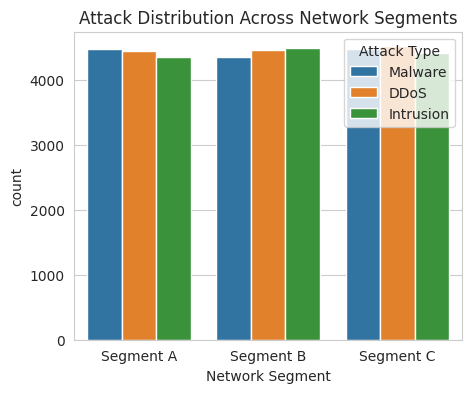

In [26]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='Network Segment',
    hue='Attack Type',
    data=df
)

plt.title("Attack Distribution Across Network Segments")
plt.show()

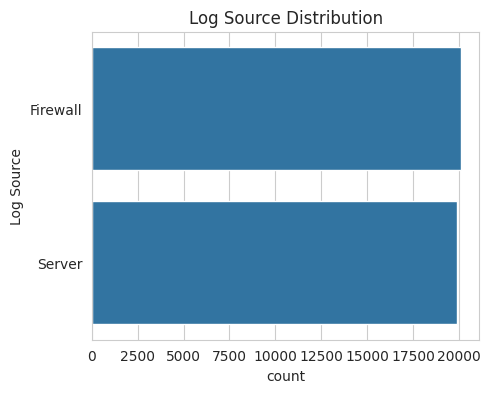

In [27]:
plt.figure(figsize=(5,4))

sns.countplot(
    y='Log Source',
    data=df,
    order=df['Log Source'].value_counts().index
)

plt.title("Log Source Distribution")
plt.show()

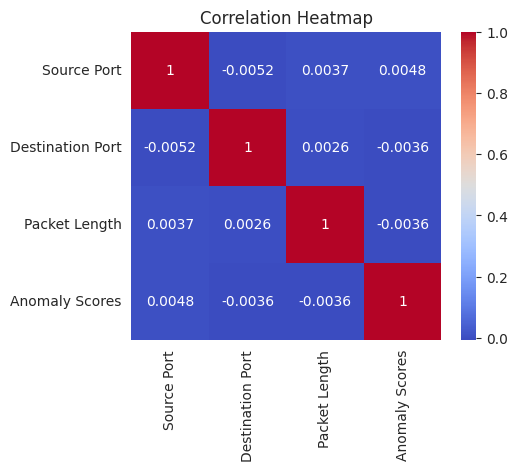

In [28]:
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(5,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

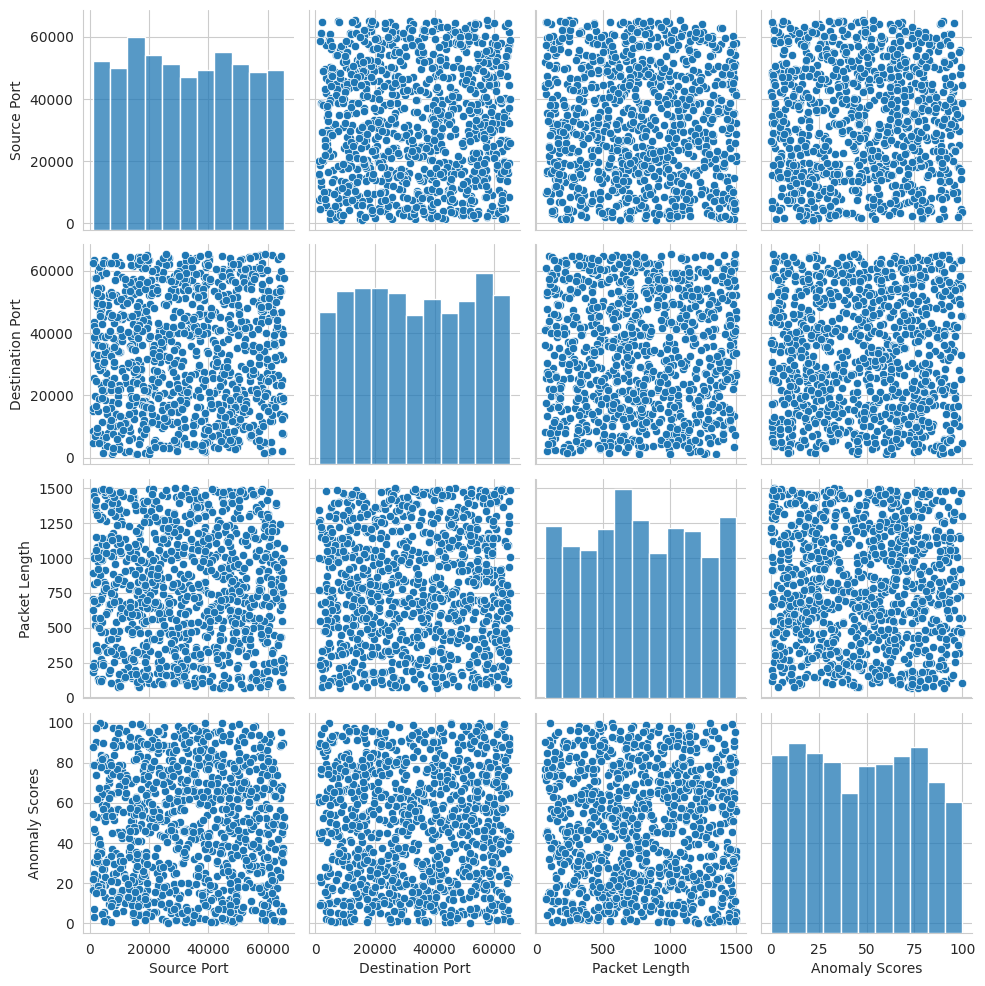

In [29]:
sns.pairplot(
    numeric_df.sample(1000)
)

plt.show()

Key Findings

1. The dataset contains 40,000 cybersecurity attack records and 25 attributes.
2. Multiple attack types are present, including malware, phishing, and DDoS attacks.
3. Severity levels vary significantly across attack categories.
4. Network protocols such as TCP, UDP, and ICMP contribute differently to traffic patterns.
5. Anomaly scores help identify suspicious activities and potential threats.
6. Certain network segments experience a higher concentration of attacks.
7. Security actions such as blocking and logging are commonly used responses.
8. Numerical feature analysis reveals patterns useful for threat detection.


Conclusion

This Exploratory Data Analysis (EDA) examined 40,000 cybersecurity attack records to uncover attack patterns, severity distributions, network behavior, and security responses. The analysis identified key trends in attack types, anomaly scores, protocol usage, and network segments. These insights can support cybersecurity teams in strengthening threat detection and improving network defense strategies.